🧠 Perceptrón desde cero
📌 1. Imports y dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generar dataset tipo "blobs" manualmente (sin sklearn)
def generate_data(n=100):
    X1 = np.random.randn(n, 2) + np.array([2, 2])
    X2 = np.random.randn(n, 2) + np.array([-2, -2])

    X = np.vstack((X1, X2))
    y = np.hstack((np.ones(n), -1*np.ones(n)))  # clases: 1 y -1

    return X, y

X, y = generate_data(100)

📊 2. Visualización inicial

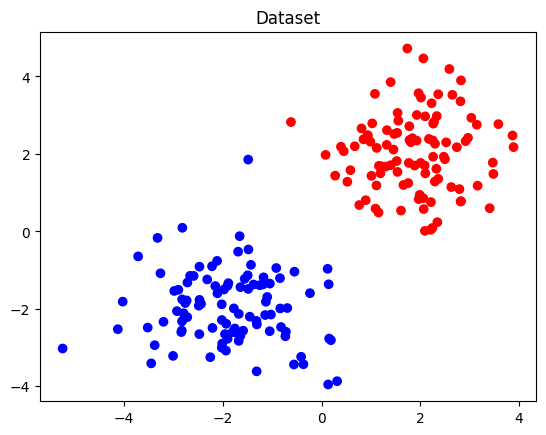

In [2]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.title("Dataset")
plt.show()

⚙️ 3. Clase Perceptron

In [3]:
class Perceptron:
    def __init__(self, lr=0.1, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors = []

    def activation(self, x):
        return np.where(x >= 0, 1, -1)

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.activation(linear)

    def train(self, X, y):
        n_features = X.shape[1]
        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()

        for epoch in range(self.epochs):
            error_count = 0

            for xi, target in zip(X, y):
                linear = np.dot(xi, self.weights) + self.bias
                y_pred = self.activation(linear)

                update = self.lr * (target - y_pred)

                self.weights += update * xi
                self.bias += update

                if update != 0:
                    error_count += 1

            self.errors.append(error_count)

📈 4. Función para graficar la recta de decisión

In [4]:
def plot_decision_boundary(X, y, model, title):
    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')

    x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)

    # recta: w1*x1 + w2*x2 + b = 0 → x2 = ...
    if model.weights[1] != 0:
        y_vals = -(model.weights[0]*x_vals + model.bias) / model.weights[1]
        plt.plot(x_vals, y_vals, 'k--')

    plt.title(title)
    plt.show()

🚀 5. Entrenamiento

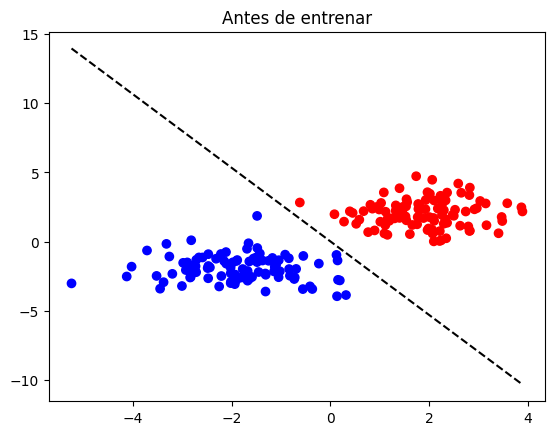

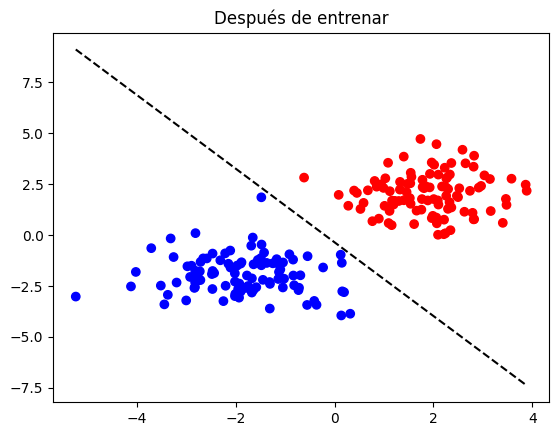

In [5]:
model = Perceptron(lr=0.1, epochs=50)

# Antes de entrenar
model.weights = np.random.randn(2)
model.bias = np.random.randn()
plot_decision_boundary(X, y, model, "Antes de entrenar")

# Entrenar
model.train(X, y)

# Después de entrenar
plot_decision_boundary(X, y, model, "Después de entrenar")

📉 6. Error por época

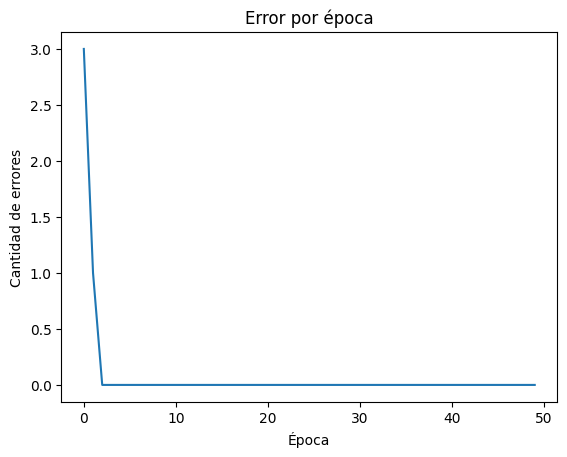

In [6]:
plt.plot(model.errors)
plt.title("Error por época")
plt.xlabel("Época")
plt.ylabel("Cantidad de errores")
plt.show()

🔬 7. Datos NO linealmente separables

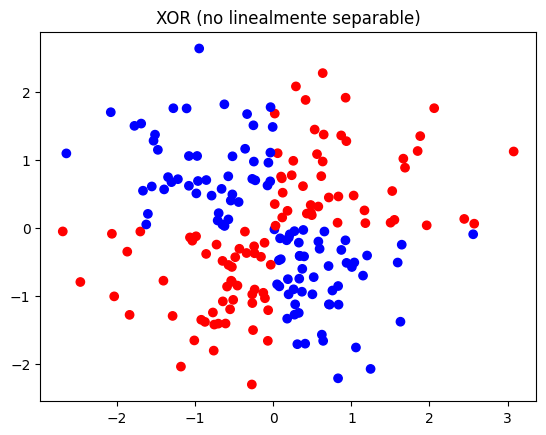

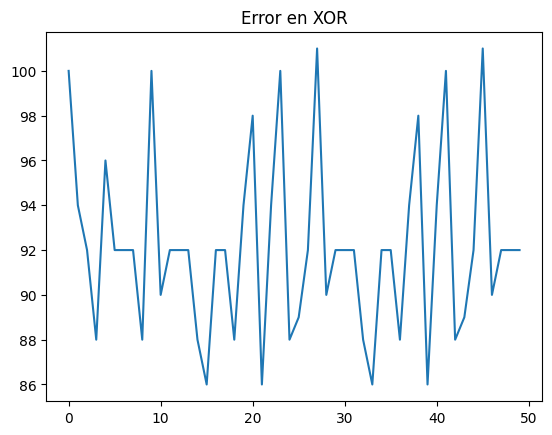

In [7]:
def generate_xor(n=100):
    X = np.random.randn(n, 2)
    y = np.sign(X[:,0] * X[:,1])
    return X, y

X_xor, y_xor = generate_xor(200)

plt.scatter(X_xor[:,0], X_xor[:,1], c=y_xor, cmap='bwr')
plt.title("XOR (no linealmente separable)")
plt.show()

model_xor = Perceptron(lr=0.1, epochs=50)
model_xor.train(X_xor, y_xor)

plt.plot(model_xor.errors)
plt.title("Error en XOR")
plt.show()